In [120]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "DataSet" / "secom.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import datetime as dt
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, r2_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, _tree, plot_tree
from xgboost import XGBClassifier, XGBRegressor


PCA 保留 131 個主成分
cluster sizes: {0: 1563, 1: 4}
cluster     0  1
y               
0        1460  3
1         103  1


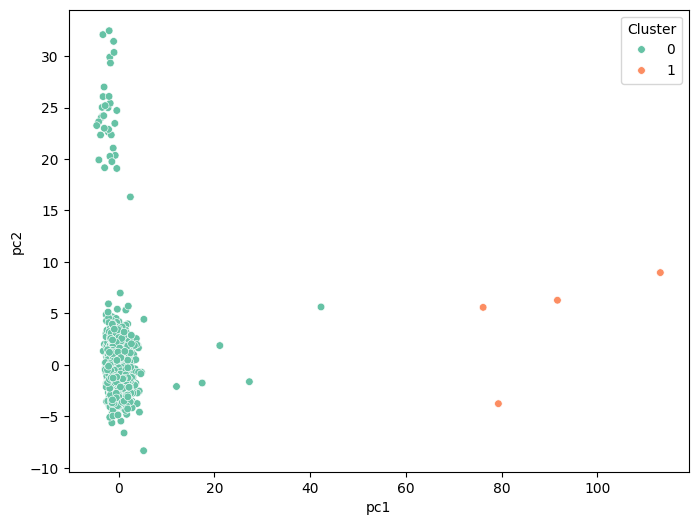

In [2]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, 132)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()

---
---

In [121]:
def local_surrogate_lattice_cube_linear(
    x0,
    blackbox_model,
    scaler=None,
    n_samples=500,
    delta=0.1,                 # 標準化空間格點步長
    k=None,                    # 若給定則固定半徑層數；否則依 n_samples 自動估
    max_full_grid=200_000,     # 允許完整展開的最大點數
    random_state=None,
):
    rng = np.random.default_rng(random_state)

    # 1) x0 -> 標準化空間
    x0 = np.asarray(x0, dtype=float).reshape(1, -1)
    x0_scaled = scaler.transform(x0) if scaler is not None else x0.copy()
    p = x0_scaled.shape[1]
    if p < 1:
        raise ValueError("x0 必須至少有 1 個特徵")
    if n_samples < 1:
        raise ValueError("n_samples must be >= 1")

    # 2) 決定 k：使 (2k+1)^p >= n_samples（僅用於定義 cube 範圍）
    if k is None:
        # 取最小 k 讓總格點數 >= n_samples（理論上，實作用浮點估算再校正）
        k_est = (n_samples ** (1.0 / p) - 1.0) / 2.0
        k = int(np.ceil(max(0.0, k_est)))
        k = max(1, k) if n_samples > 1 else 0
    else:
        k = int(k)
        if k < 0:
            raise ValueError("k must be >= 0")

    total = (2 * k + 1) ** p if k > 0 else 1

    # 3) 生成 offsets：m ∈ {-k,...,k}^p
    #    - total 小：展開 full grid 再截取/洗牌
    #    - total 大：直接在整數 cube 上抽樣 n_samples 個 m（仍是格點）
    if total <= max_full_grid:
        grid_1d = np.arange(-k, k + 1, dtype=float)
        meshes = np.meshgrid(*([grid_1d] * p), indexing="ij")
        offsets = np.stack(meshes, axis=-1).reshape(-1, p)  # (total, p)

        # 把中心 0 向量放在第 0 個，其他洗牌後取 n_samples
        # 找到全零那列
        zero_idx = np.where((offsets == 0).all(axis=1))[0][0]
        if zero_idx != 0:
            offsets[[0, zero_idx]] = offsets[[zero_idx, 0]]

        if len(offsets) > 1:
            perm = np.arange(1, len(offsets))
            rng.shuffle(perm)
            offsets = np.vstack([offsets[0], offsets[perm]])

        offsets = offsets[:n_samples] if len(offsets) >= n_samples else offsets
        mode = "full_grid"
    else:
        offsets = rng.integers(-k, k + 1, size=(n_samples, p)).astype(float)
        offsets[0, :] = 0.0  # 強制包含中心
        mode = "sampled_grid"

    # 4) 形成 lattice cube 設計點（標準化空間）
    Z_scaled = x0_scaled + delta * offsets

    # 5) 還原回原始空間（給 blackbox）
    Z = scaler.inverse_transform(Z_scaled) if scaler is not None else Z_scaled.copy()

    # 6) blackbox oracle 產生 pseudo-label
    if hasattr(blackbox_model, "predict_proba"):
        y_local = blackbox_model.predict_proba(Z)[:, 1]
    else:
        y_local = blackbox_model.predict(Z)
    y_local = np.asarray(y_local, dtype=float).reshape(-1)

    # 7) \hat{\hat g}：Linear Regression（在標準化空間擬合）
    g_hat_hat = LinearRegression()
    g_hat_hat.fit(Z_scaled, y_local)

    # 8) 線性模型常用 criterion：R2 / adj-R2 / AIC / BIC
    n = Z_scaled.shape[0]
    r2 = g_hat_hat.score(Z_scaled, y_local)
    y_hat = g_hat_hat.predict(Z_scaled)
    resid = y_local - y_hat
    sse = float(resid @ resid)
    mse = sse / n if n > 0 else np.nan

    # Adjusted R2
    if n > p + 1:
        adj_r2 = 1.0 - (1.0 - r2) * (n - 1) / (n - p - 1)
    else:
        adj_r2 = np.nan

    # AIC/BIC（高斯誤差近似；k_params = p 斜率 + 1 截距）
    k_params = p + 1
    if n > 0 and sse > 0:
        aic = n * np.log(sse / n) + 2 * k_params
        bic = n * np.log(sse / n) + np.log(n) * k_params
    else:
        aic = -np.inf
        bic = -np.inf

    info = {
        "mode": mode,                 # full_grid / sampled_grid
        "k": k,
        "delta": delta,
        "Z": Z,                       # 原始空間設計點（給 blackbox）
        "Z_scaled": Z_scaled,         # 標準化空間設計點（給 surrogate）
        "offsets": offsets,           # m ∈ {-k,...,k}^p（或其子集）
        "y_blackbox": y_local,
        "y_surrogate": y_hat,
        "r2": float(r2),
        "adj_r2": float(adj_r2) if np.isfinite(adj_r2) else adj_r2,
        "aic": float(aic),
        "bic": float(bic),
        "mse": float(mse) if np.isfinite(mse) else mse,
        "coef_scaled": g_hat_hat.coef_.copy(),
        "intercept": float(g_hat_hat.intercept_),
    }
    # --- OLS summary (最小增量) ---
    X_ols = sm.add_constant(Z_scaled)          # 截距
    ols_res = sm.OLS(y_hat, X_ols).fit()
    info["ols_summary"] = ols_res.summary().as_text()
    return g_hat_hat, info


---
---

依照KMEANS分的cluster=0/1各自去做surrogate

In [96]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
n_real = len(X_std)

# 必要斷言：確保前段就是原始點
assert np.allclose(X_smote_df.iloc[:n_real].values, X_std.values, atol=0, rtol=0)
assert np.array_equal(np.asarray(y_smote)[:n_real], np.asarray(y))

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

# X_smote_df 目前包含所有特徵 + "cluster"
X_smote_df["cluster"] = cluster

# 確保 X_all_df 不含 cluster 欄
X_feat_df = X_smote_df.drop(columns=["cluster"]).copy()
# 只取真實點（不含 SMOTE 合成點）來做 local surrogate 與訓練每群 blackbox
X_all_df = X_feat_df.iloc[:n_real].copy() # 真實點特徵（標準化空間）
c_all = X_smote_df.loc[:n_real-1, "cluster"].to_numpy() # 真實點分群
y_real = np.asarray(y) # 真實 y

# ========= per-cluster blackbox =========
def fit_blackbox_per_cluster(X_all_df, y_all, c_all):
    models = {}
    y_all = np.asarray(y_all)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx]
        yc = y_all[idx]

        m = XGBRegressor(n_estimators=300,
            max_depth=3,
            learning_rate=0.10,
            subsample=0.7,
            colsample_bytree=0.7,
            min_child_weight=10,
            gamma=1.0,
            reg_lambda=2.0,
            reg_alpha=0.5,
            random_state=42,
            n_jobs=-1,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            )
        models[c] = m.fit(Xc, yc)
    return models

blackbox_by_c = fit_blackbox_per_cluster(X_all_df, y_real, c_all)

# ========= x0 挑選（在各群內、用該群 blackbox 的 p_hat） =========
def pick_x0_indices(p, target, topk=10, min_p=None):
    p = np.asarray(p).reshape(-1)
    idx = np.arange(len(p))
    if min_p is not None:
        idx = idx[p[idx] >= min_p]
    if idx.size == 0:
        return idx
    order = np.argsort(np.abs(p[idx] - target))
    return idx[order[:min(topk, idx.size)]]

# ========= per-cluster local surrogate =========
def run_local_surrogates_per_cluster(
    X_all_df, c_all, blackbox_by_c,
    n_samples=500, delta=0.5, topk=10, random_state=42
):
    all_infos = []

    for c in sorted(blackbox_by_c.keys()):
        idx_c = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx_c]
        m  = blackbox_by_c[c]

        p_hat_c = m.predict(Xc.values)

        # 兩組 x0：p≈0.5 與 p≈1
        loc_05 = pick_x0_indices(p_hat_c, target=0.5, topk=topk)
        loc_1  = pick_x0_indices(p_hat_c, target=1.0, topk=topk, min_p=0.99)

        def _one_group(loc_idx, tag):
            infos = []
            for j, pos in enumerate(loc_idx):
                global_idx = int(idx_c[pos])
                x0 = X_all_df.iloc[global_idx].to_numpy()

                g, info = local_surrogate_lattice_cube_linear(
                    x0=x0,
                    blackbox_model=m,   # 用該群 blackbox
                    scaler=None,        # 已在標準化空間
                    n_samples=n_samples,
                    delta=delta,
                    k=None,
                    max_full_grid=200_000,
                    random_state=random_state
                )
                info["cluster"]   = int(c)
                info["group"]     = tag
                info["i"]         = int(j)
                info["x0_index"]  = global_idx
                info["p_hat_x0"]  = float(info["y_blackbox"][0])
                infos.append(info)
            return infos

        all_infos.extend(_one_group(loc_05, "p≈0.5"))
        all_infos.extend(_one_group(loc_1,  "p≈1(fail)"))

    return all_infos

infos_all = run_local_surrogates_per_cluster(
    X_all_df=X_all_df,
    c_all=c_all,
    blackbox_by_c=blackbox_by_c,
    n_samples=500,
    delta=0.5,
    topk=10,
    random_state=42
)

# ========= metrics 表 =========
def infos_to_metrics_df(infos):
    rows = []
    for d in infos:
        rows.append({
            "cluster": d.get("cluster", None),
            "group": d.get("group", None),
            "i": d.get("i", None),
            "x0_index": d.get("x0_index", None),
            "p_hat_x0": d.get("p_hat_x0", np.nan),
            "r2": d.get("r2", np.nan),
            "adj_r2": d.get("adj_r2", np.nan),
            "aic": d.get("aic", np.nan),
            "bic": d.get("bic", np.nan),
            "mse": d.get("mse", np.nan),
            "k": d.get("k", None),
            "delta": d.get("delta", None),
            "mode": d.get("mode", None),
        })
    return pd.DataFrame(rows).sort_values(["cluster", "group", "i"]).reset_index(drop=True)

df_metrics = infos_to_metrics_df(infos_all)
df_metrics

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個


C:\Users\USER\AppData\Local\Temp\ipykernel_12004\4020321248.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_smote_df["cluster"] = cluster


,cluster,group,i,x0_index,p_hat_x0,r2,adj_r2,aic,bic,mse,k,delta,mode
0,0,p≈0.5,0,461,0.306023,0.961367,0.518049,-3669.445410,-1730.725685,0.000103,1,0.5,sampled_grid
1,0,p≈0.5,1,541,0.247392,0.969893,0.624414,-4023.876283,-2085.156557,0.000051,1,0.5,sampled_grid
2,0,p≈0.5,2,1287,0.238374,0.963794,0.548334,-4024.050214,-2085.330489,0.000051,1,0.5,sampled_grid
3,0,p≈0.5,3,1361,0.231784,0.970299,0.629476,-4190.977189,-2252.257464,0.000036,1,0.5,sampled_grid
4,0,p≈0.5,4,1305,0.209534,0.962672,0.534339,-4123.780968,-2185.061243,0.000042,1,0.5,sampled_grid
5,0,p≈0.5,5,507,0.201588,0.976944,0.712370,-4032.240165,-2093.520440,0.000050,1,0.5,sampled_grid
6,0,p≈0.5,6,1184,0.196682,0.975215,0.690813,-4195.355360,-2256.635635,0.000036,1,0.5,sampled_grid
7,0,p≈0.5,7,1216,0.191857,0.976999,0.713058,-4526.146747,-2587.427022,0.000019,1,0.5,sampled_grid
8,0,p≈0.5,8,1326,0.187411,0.970629,0.633597,-4143.512181,-2204.792456,0.000040,1,0.5,sampled_grid
9,0,p≈0.5,9,1210,0.182044,0.961372,0.518122,-4153.365262,-2214.645537,0.000039,1,0.5,sampled_grid


In [125]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
n_real = len(X_std)

# 必要斷言：確保前段就是原始點
assert np.allclose(X_smote_df.iloc[:n_real].values, X_std.values, atol=0, rtol=0)
assert np.array_equal(np.asarray(y_smote)[:n_real], np.asarray(y))

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

# X_smote_df 目前包含所有特徵 + "cluster"
X_smote_df["cluster"] = cluster

# 確保 X_all_df 不含 cluster 欄
X_feat_df = X_smote_df.drop(columns=["cluster"]).copy()
# 只取真實點（不含 SMOTE 合成點）來做 local surrogate 與訓練每群 blackbox
X_all_df = X_feat_df.iloc[:n_real].copy() # 真實點特徵（標準化空間）
c_all = X_smote_df.loc[:n_real-1, "cluster"].to_numpy() # 真實點分群
y_real = np.asarray(y) # 真實 y

def oof_proba_per_cluster(X_all_df, y_all, c_all, n_splits=5, random_state=42):
    y_all = np.asarray(y_all).astype(int)
    p_oof = np.full(len(y_all), np.nan, dtype=float)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        for tr, te in skf.split(Xc, yc):
            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]

            # 只對 training 做 SMOTE（不把合成樣本寫入 p_oof）
            sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
            X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
            m.fit(X_tr, y_tr)
            p_oof[idx[te]] = m.predict_proba(X_te)[:, 1]

    return p_oof

def fit_blackbox_per_cluster(X_all_df, y_all, c_all):
    models = {}
    y_all = np.asarray(y_all)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=42,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
        models[c] = m.fit(Xc, yc)

    return models

# 1) 先算每群 OOF 機率（用來挑 x0）
p_hat_oof = oof_proba_per_cluster(X_all_df, y_real, c_all)

# 2) 用 p_hat_oof 在各群挑 \hat p \approx 0.5 的 x0（你的 pick_x0_local_indices 直接餵 p_hat_oof[群內] 即可）
#    例：群 c 的 idx_c = np.where(c_all==c)[0]，再在 p_hat_oof[idx_c] 上挑最近 0.5 的點。

# 3) 最後用全資料重訓每群最終黑箱（用於 lattice 探測與 surrogate 擬合）
blackbox_by_c = fit_blackbox_per_cluster(X_all_df, y_real, c_all)


# ========= x0 挑選（在各群內、用該群 blackbox 的 p_hat） =========
def pick_x0_indices(p, target, topk=10, min_p=None):
    p = np.asarray(p).reshape(-1)
    idx = np.arange(len(p))
    if min_p is not None:
        idx = idx[p[idx] >= min_p]
    if idx.size == 0:
        return idx
    order = np.argsort(np.abs(p[idx] - target))
    return idx[order[:min(topk, idx.size)]]

# ========= per-cluster local surrogate =========
def run_local_surrogates_per_cluster(
    X_all_df, c_all, blackbox_by_c, p_hat_oof,
    n_samples=500, delta=0.5, topk=10, random_state=42
):
    all_infos = []

    for c in sorted(blackbox_by_c.keys()):
        idx_c = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx_c]
        m  = blackbox_by_c[c]

        p_hat_c = np.asarray(p_hat_oof)[idx_c]

        # 兩組 x0：p≈0.5 與 p≈1
        loc_05 = pick_x0_indices(p_hat_c, target=0.5, topk=topk)
        loc_1  = pick_x0_indices(p_hat_c, target=1, topk=topk)

        def _one_group(loc_idx, tag):
            infos = []
            for j, pos in enumerate(loc_idx):
                global_idx = int(idx_c[pos])
                x0 = X_all_df.iloc[global_idx].to_numpy()

                g, info = local_surrogate_lattice_cube_linear(
                    x0=x0,
                    blackbox_model=m,   # 用該群 blackbox
                    scaler=None,        # 已在標準化空間
                    n_samples=n_samples,
                    delta=delta,
                    k=None,
                    max_full_grid=200_000,
                    random_state=random_state
                )
                info["cluster"]   = int(c)
                info["group"]     = tag
                info["i"]         = int(j)
                info["x0_index"]  = global_idx
                info["p_hat_x0"]  = float(info["y_blackbox"][0])
                infos.append(info)
            return infos

        all_infos.extend(_one_group(loc_05, "p≈0.5"))
        all_infos.extend(_one_group(loc_1,  "p≈1(fail)"))

    return all_infos

infos_all = run_local_surrogates_per_cluster(
    X_all_df=X_all_df,
    c_all=c_all,
    blackbox_by_c=blackbox_by_c,
    p_hat_oof=p_hat_oof,
    n_samples=500,
    delta=0.5,
    topk=10,
    random_state=42
)

# ========= metrics 表 =========
def infos_to_metrics_df(infos):
    rows = []
    for d in infos:
        rows.append({
            "cluster": d.get("cluster", None),
            "group": d.get("group", None),
            "i": d.get("i", None),
            "x0_index": d.get("x0_index", None),
            "p_hat_x0": d.get("p_hat_x0", np.nan),
            "r2": d.get("r2", np.nan),
            "adj_r2": d.get("adj_r2", np.nan),
            "aic": d.get("aic", np.nan),
            "bic": d.get("bic", np.nan),
            "mse": d.get("mse", np.nan),
            "k": d.get("k", None),
            "delta": d.get("delta", None),
            "mode": d.get("mode", None),
        })
    return pd.DataFrame(rows).sort_values(["cluster", "group", "i"]).reset_index(drop=True)

df_metrics = infos_to_metrics_df(infos_all)
df_metrics

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個


C:\Users\USER\AppData\Local\Temp\ipykernel_12004\3388406835.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_smote_df["cluster"] = cluster


,cluster,group,i,x0_index,p_hat_x0,r2,adj_r2,aic,bic,mse,k,delta,mode
0,0,p≈0.5,0,1361,0.668933,0.970844,0.636284,-2962.833593,-1024.113867,0.000424,1,0.5,sampled_grid
1,0,p≈0.5,1,995,0.114982,0.970814,0.635907,-4060.243434,-2121.523709,0.000047,1,0.5,sampled_grid
2,0,p≈0.5,2,1108,0.069746,0.978048,0.726143,-3885.770316,-1947.050591,0.000067,1,0.5,sampled_grid
3,0,p≈0.5,3,1227,0.096401,0.979132,0.739674,-3952.549953,-2013.830228,0.000059,1,0.5,sampled_grid
4,0,p≈0.5,4,507,0.113755,0.974043,0.676182,-3578.834216,-1640.114491,0.000124,1,0.5,sampled_grid
5,0,p≈0.5,5,1180,0.095218,0.977423,0.718347,-3977.516817,-2038.797092,0.000056,1,0.5,sampled_grid
6,0,p≈0.5,6,1296,0.067913,0.980725,0.759538,-4603.468868,-2664.749142,0.000016,1,0.5,sampled_grid
7,0,p≈0.5,7,1321,0.118757,0.969053,0.613932,-3921.912650,-1983.192925,0.000062,1,0.5,sampled_grid
8,0,p≈0.5,8,1308,0.043016,0.978497,0.731745,-4701.446813,-2762.727087,0.000013,1,0.5,sampled_grid
9,0,p≈0.5,9,1215,0.040970,0.977179,0.715308,-4187.882596,-2249.162871,0.000037,1,0.5,sampled_grid


In [127]:
print(infos_all[5]["ols_summary"])

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.326e+26
Date:                Mon, 12 Jan 2026   Prob (F-statistic):               0.00
Time:                        11:50:20   Log-Likelihood:                 16445.
No. Observations:                 500   AIC:                        -3.197e+04
Df Residuals:                      40   BIC:                        -3.003e+04
Df Model:                         459                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2039   2.15e-14  -9.47e+12      0.0

In [101]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
n_real = len(X_std)

# 必要斷言：確保前段就是原始點
assert np.allclose(X_smote_df.iloc[:n_real].values, X_std.values, atol=0, rtol=0)
assert np.array_equal(np.asarray(y_smote)[:n_real], np.asarray(y))

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

# X_smote_df 目前包含所有特徵 + "cluster"
X_smote_df["cluster"] = cluster

# 確保 X_all_df 不含 cluster 欄
X_feat_df = X_smote_df.drop(columns=["cluster"]).copy()
# 只取真實點（不含 SMOTE 合成點）來做 local surrogate 與訓練每群 blackbox
X_all_df = X_feat_df.iloc[:n_real].copy() # 真實點特徵（標準化空間）
c_all = X_smote_df.loc[:n_real-1, "cluster"].to_numpy() # 真實點分群
y_real = np.asarray(y) # 真實 y

def oof_proba_and_cm_per_cluster(
    X_all_df,
    y_all,
    c_all,
    n_splits=5,
    random_state=42,
    threshold=0.5,
    labels=(0, 1),
):
    """
    分群後各群各自做 StratifiedKFold；每折用該折 test 產生 confusion matrix；
    同時回傳整體 OOF proba，以及「每群」的 fold-level 與 OOF-level confusion matrix。

    回傳：
      p_oof: (N,) 全資料的 OOF proba
      cm_dict: {
        cluster: {
          "fold_cm": [2x2 cm, ...],
          "fold_counts": [{"fold":i,"tn":..,"fp":..,"fn":..,"tp":..}, ...],
          "sum_fold_cm": 2x2 cm,
          "oof_cm": 2x2 cm,      # 用該群所有 idx 的 OOF 預測彙總
          "n_splits_used": int
        }, ...
      }
    """
    y_all = np.asarray(y_all).astype(int)
    c_all = np.asarray(c_all)
    n = len(y_all)

    p_oof = np.full(n, np.nan, dtype=float)
    cm_dict = {}

    clusters = np.unique(c_all)

    for c in clusters:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

        fold_cms = []
        fold_counts = []
        sum_cm = np.zeros((2, 2), dtype=int)

        for fold_i, (tr, te) in enumerate(skf.split(Xc, yc), start=1):
            sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
            X_tr, y_tr = sm.fit_resample(Xc[tr], yc[tr])
            m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
            m.fit(X_tr, y_tr)

            proba = m.predict_proba(Xc[te])[:, 1]
            p_oof[idx[te]] = proba

            y_pred = (proba >= threshold).astype(int)
            cm = confusion_matrix(yc[te], y_pred, labels=list(labels))

            fold_cms.append(cm)
            sum_cm += cm

            tn, fp, fn, tp = cm.ravel()
            fold_counts.append(
                {"fold": fold_i, "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}
            )

        # 該群 OOF 彙總 confusion matrix（用該群所有 idx 的 OOF 預測）
        proba_c = p_oof[idx]
        mask = np.isfinite(proba_c)
        y_pred_oof = (proba_c[mask] >= threshold).astype(int)
        y_true_oof = yc[mask]
        oof_cm = confusion_matrix(y_true_oof, y_pred_oof, labels=list(labels))

        cm_dict[c] = {
            "fold_cm": fold_cms,
            "fold_counts": fold_counts,
            "sum_fold_cm": sum_cm,
            "oof_cm": oof_cm,
            "n_splits_used": n_splits,
        }

    return p_oof, cm_dict


def print_cluster_cms(cm_dict):
    for c, d in cm_dict.items():
        print(f"\n=== Cluster {c} | n_splits_used={d['n_splits_used']} ===")

        for i, cm in enumerate(d["fold_cm"], start=1):
            tn, fp, fn, tp = cm.ravel()
            print(f"\n[Fold {i}] CM:\n{cm}")
            print(f"TN={tn} FP={fp} FN={fn} TP={tp}")

        print(f"\n[Sum of folds] CM:\n{d['sum_fold_cm']}")
        tn, fp, fn, tp = d["sum_fold_cm"].ravel()
        print(f"TN={tn} FP={fp} FN={fn} TP={tp}")

        print(f"\n[OOF aggregated] CM:\n{d['oof_cm']}")
        tn, fp, fn, tp = d["oof_cm"].ravel()
        print(f"TN={tn} FP={fp} FN={fn} TP={tp}")

# 使用方式
p_oof, cm_dict = oof_proba_and_cm_per_cluster(
    X_all_df=X_all_df,
    y_all=y_real,
    c_all=c_all,
    n_splits=5,
    random_state=42,
    threshold=0.5,
)

print_cluster_cms(cm_dict)

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個


C:\Users\USER\AppData\Local\Temp\ipykernel_12004\1209669452.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_smote_df["cluster"] = cluster



=== Cluster 0 | n_splits_used=5 ===

[Fold 1] CM:
[[148   1]
 [  5   1]]
TN=148 FP=1 FN=5 TP=1

[Fold 2] CM:
[[146   3]
 [  6   0]]
TN=146 FP=3 FN=6 TP=0

[Fold 3] CM:
[[145   4]
 [  4   1]]
TN=145 FP=4 FN=4 TP=1

[Fold 4] CM:
[[148   0]
 [  4   2]]
TN=148 FP=0 FN=4 TP=2

[Fold 5] CM:
[[147   1]
 [  6   0]]
TN=147 FP=1 FN=6 TP=0

[Sum of folds] CM:
[[734   9]
 [ 25   4]]
TN=734 FP=9 FN=25 TP=4

[OOF aggregated] CM:
[[734   9]
 [ 25   4]]
TN=734 FP=9 FN=25 TP=4

=== Cluster 1 | n_splits_used=5 ===

[Fold 1] CM:
[[127  11]
 [ 11   2]]
TN=127 FP=11 FN=11 TP=2

[Fold 2] CM:
[[137   1]
 [ 12   1]]
TN=137 FP=1 FN=12 TP=1

[Fold 3] CM:
[[129   8]
 [ 13   1]]
TN=129 FP=8 FN=13 TP=1

[Fold 4] CM:
[[135   2]
 [ 10   3]]
TN=135 FP=2 FN=10 TP=3

[Fold 5] CM:
[[133   4]
 [ 10   3]]
TN=133 FP=4 FN=10 TP=3

[Sum of folds] CM:
[[661  26]
 [ 56  10]]
TN=661 FP=26 FN=56 TP=10

[OOF aggregated] CM:
[[661  26]
 [ 56  10]]
TN=661 FP=26 FN=56 TP=10


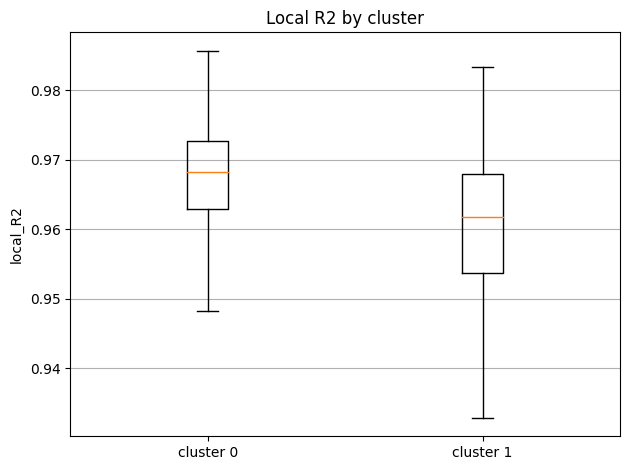

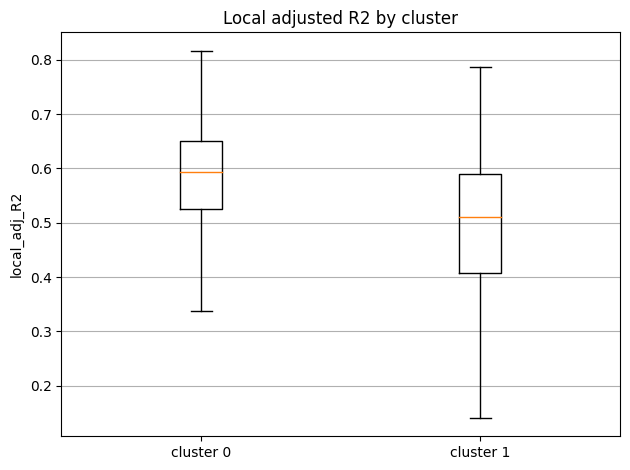

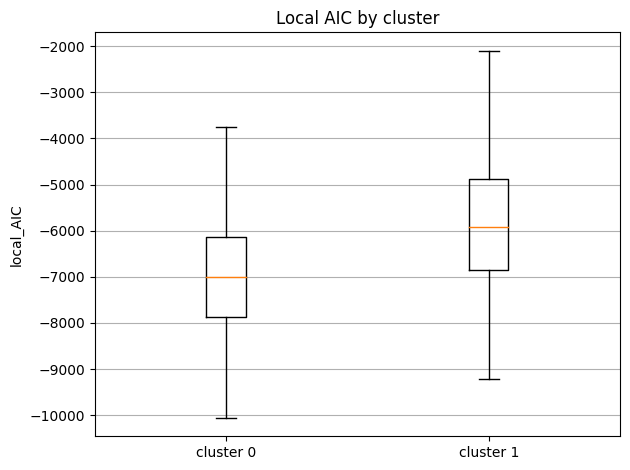

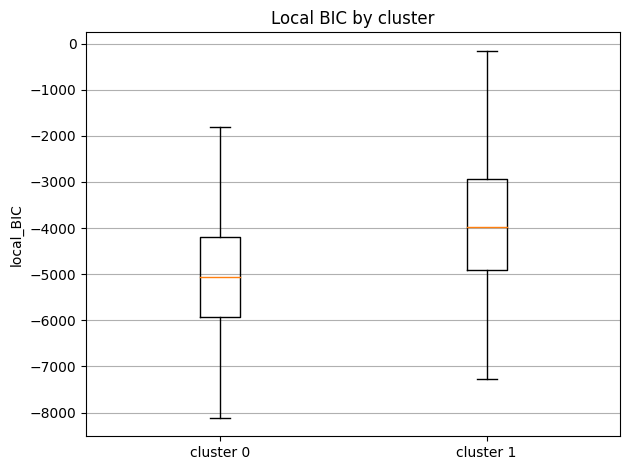

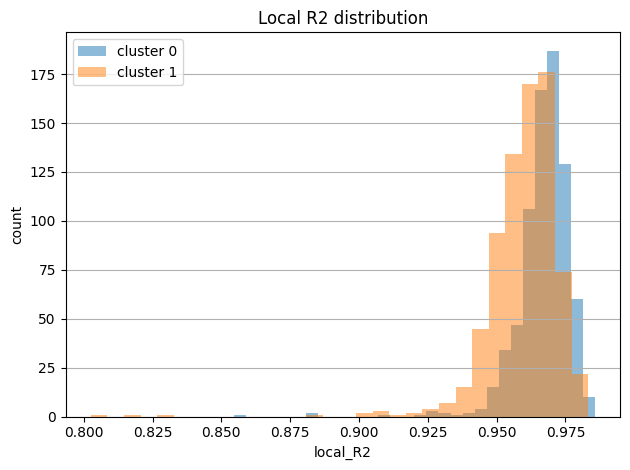

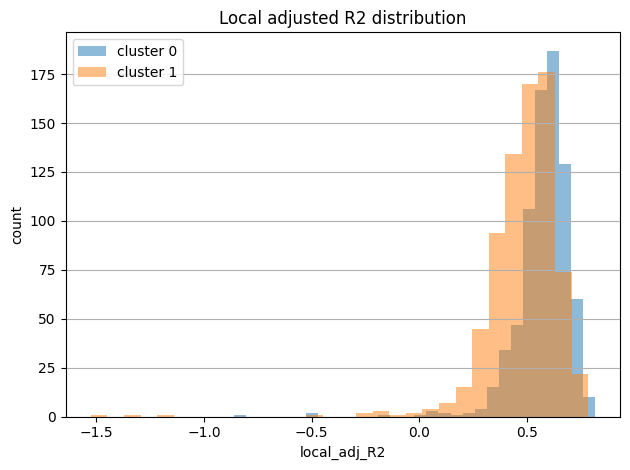

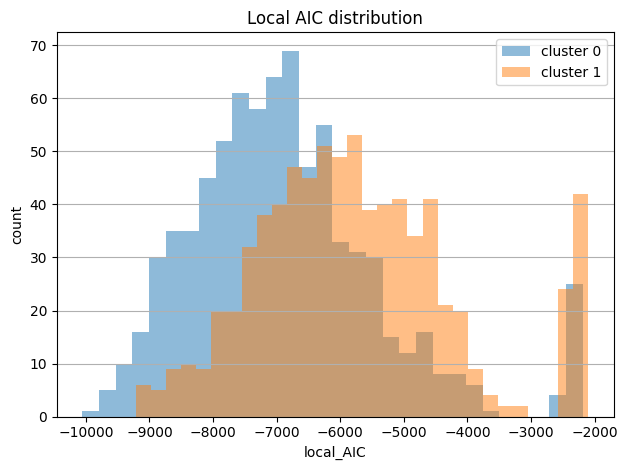

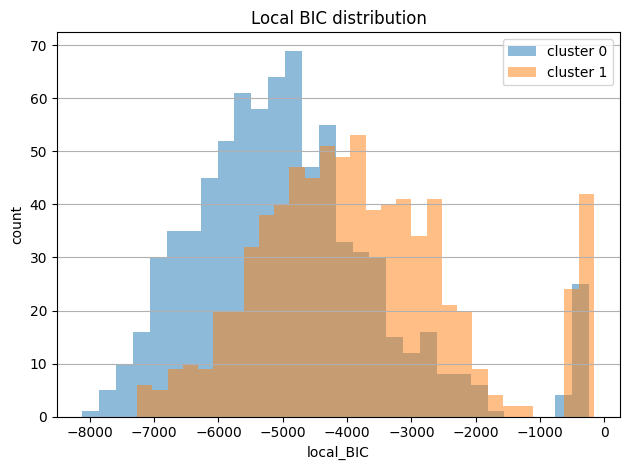

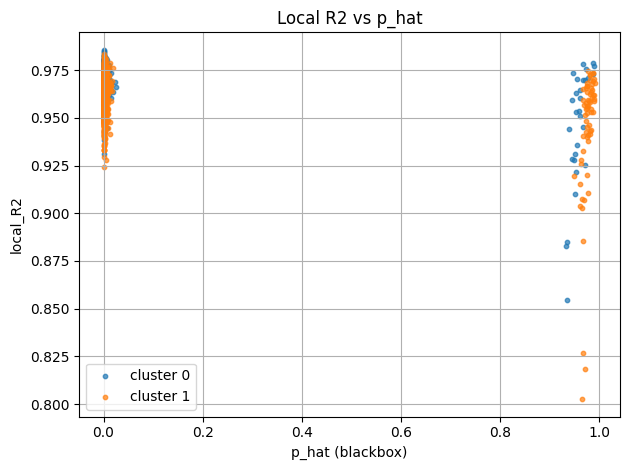

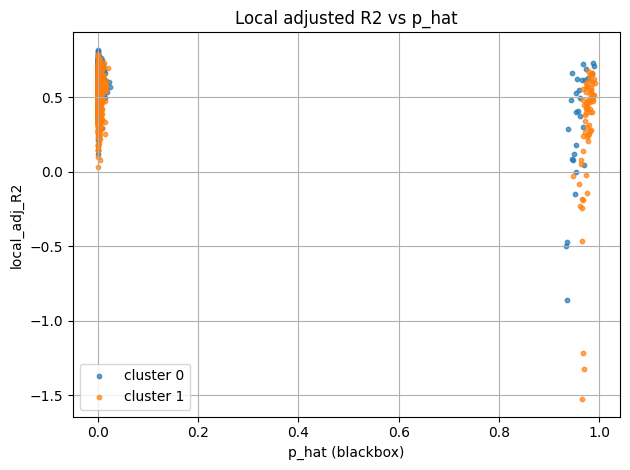

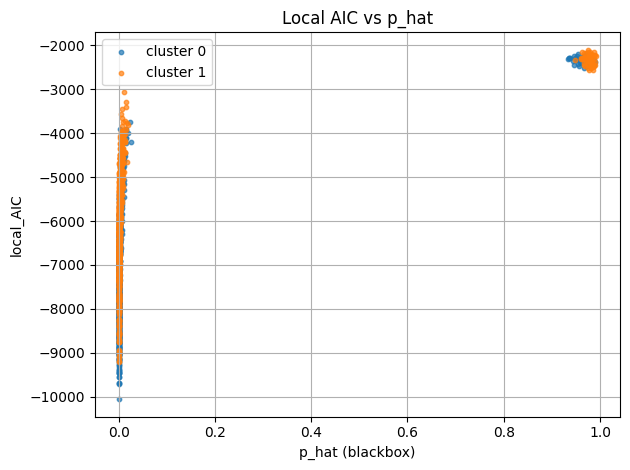

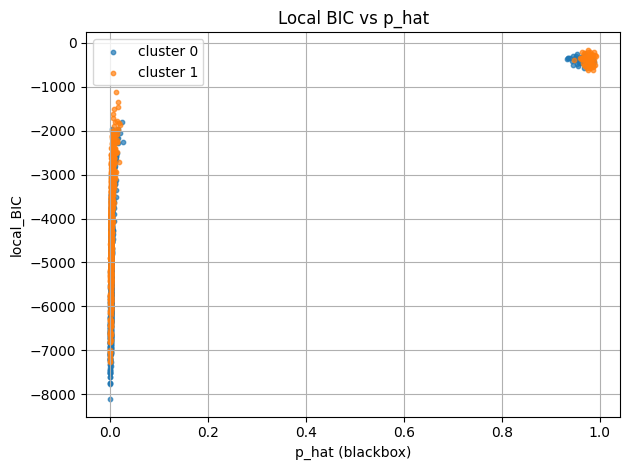

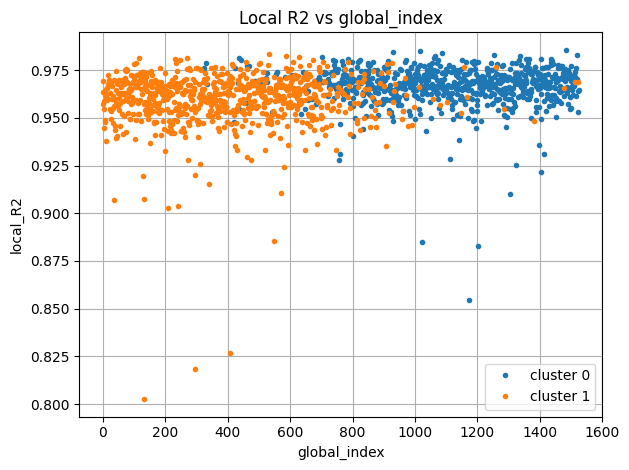

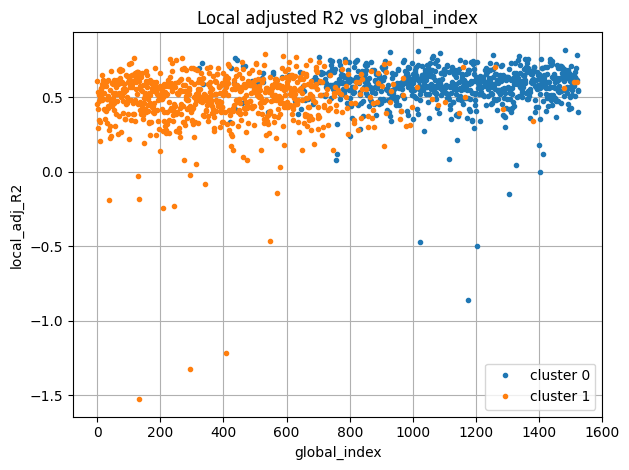

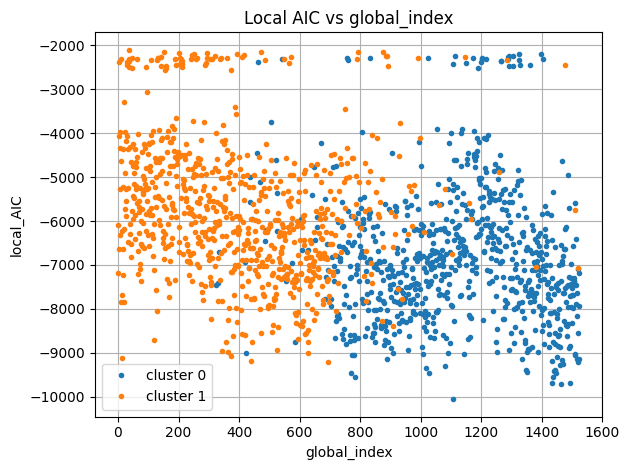

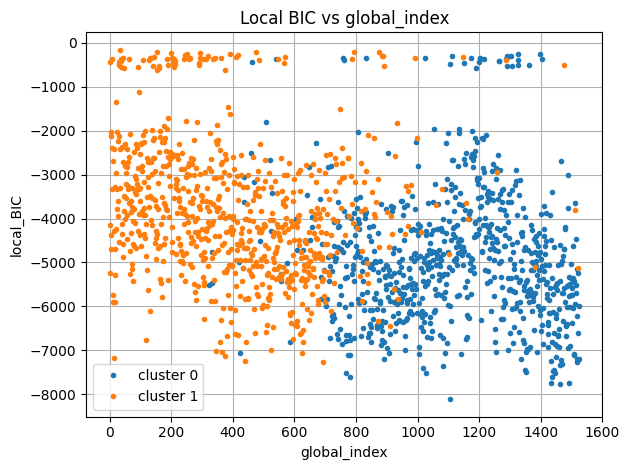

In [81]:

def _boxplot_by_cluster(df, col, title):
    groups = []
    labels = []
    for c in sorted(df["cluster"].unique()):
        groups.append(df.loc[df["cluster"] == c, col].dropna().values)
        labels.append(f"cluster {c}")
    plt.figure()
    plt.boxplot(groups, labels=labels, showfliers=False)
    plt.title(title)
    plt.ylabel(col)
    plt.grid(True, axis="y")
    plt.tight_layout()

def _hist_by_cluster(df, col, title, bins=30):
    plt.figure()
    for c in sorted(df["cluster"].unique()):
        x = df.loc[df["cluster"] == c, col].dropna().values
        plt.hist(x, bins=bins, alpha=0.5, label=f"cluster {c}")
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel("count")
    plt.legend()
    plt.grid(True, axis="y")
    plt.tight_layout()

def _scatter_p_hat(df, col, title):
    plt.figure()
    for c in sorted(df["cluster"].unique()):
        sub = df[df["cluster"] == c]
        plt.scatter(sub["p_hat"].values, sub[col].values, s=10, alpha=0.7, label=f"cluster {c}")
    plt.title(title)
    plt.xlabel("p_hat (blackbox)")
    plt.ylabel(col)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

def _series_global_index(df, col, title):
    plt.figure()
    sub = df.sort_values("global_index")
    for c in sorted(sub["cluster"].unique()):
        s = sub[sub["cluster"] == c]
        plt.plot(s["global_index"].values, s[col].values, marker=".", linestyle="None", label=f"cluster {c}")
    plt.title(title)
    plt.xlabel("global_index")
    plt.ylabel(col)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

# 1) 分群箱型圖（核心：分佈與離群）
_boxplot_by_cluster(local_df, "local_R2", "Local R2 by cluster")
_boxplot_by_cluster(local_df, "local_adj_R2", "Local adjusted R2 by cluster")
_boxplot_by_cluster(local_df, "local_AIC", "Local AIC by cluster")
_boxplot_by_cluster(local_df, "local_BIC", "Local BIC by cluster")

# 2) 分群直方圖（看整體分佈形狀）
_hist_by_cluster(local_df, "local_R2", "Local R2 distribution", bins=30)
_hist_by_cluster(local_df, "local_adj_R2", "Local adjusted R2 distribution", bins=30)
_hist_by_cluster(local_df, "local_AIC", "Local AIC distribution", bins=30)
_hist_by_cluster(local_df, "local_BIC", "Local BIC distribution", bins=30)

# 3) 指標 vs p_hat（看是否只在決策邊界附近表現不同）
_scatter_p_hat(local_df, "local_R2", "Local R2 vs p_hat")
_scatter_p_hat(local_df, "local_adj_R2", "Local adjusted R2 vs p_hat")
_scatter_p_hat(local_df, "local_AIC", "Local AIC vs p_hat")
_scatter_p_hat(local_df, "local_BIC", "Local BIC vs p_hat")

# 4) 指標 vs global_index（按資料順序檢查結構性變化）
_series_global_index(local_df, "local_R2", "Local R2 vs global_index")
_series_global_index(local_df, "local_adj_R2", "Local adjusted R2 vs global_index")
_series_global_index(local_df, "local_AIC", "Local AIC vs global_index")
_series_global_index(local_df, "local_BIC", "Local BIC vs global_index")

plt.show()

---
---

In [95]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
n_real = len(X_std)

# 必要斷言：確保前段就是原始點
assert np.allclose(X_smote_df.iloc[:n_real].values, X_std.values, atol=0, rtol=0)
assert np.array_equal(np.asarray(y_smote)[:n_real], np.asarray(y))

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

X_smote_df["cluster"] = cluster

# 只取真實點（不含 SMOTE 合成點）來做 local surrogate 與訓練每群 blackbox
X_all_df = X_smote_df.iloc[:n_real].copy()
y_real = np.asarray(y)   # 直接用真實 y

blackbox = XGBRegressor(
                        n_estimators=300,
                        max_depth=3,
                        learning_rate=0.10,
                        subsample=0.7,
                        colsample_bytree=0.7,
                        min_child_weight=10,
                        gamma=1.0,
                        reg_lambda=2.0,
                        reg_alpha=0.5,
                        random_state=42,
                        n_jobs=-1,
                        objective="binary:logistic",
                        eval_metric="logloss",
                        tree_method="hist",
                    ).fit(X_all_df, y_real)
p_hat = blackbox.predict(X_all_df.values)

# ====== 改動點 2：在真實點中挑 x0：p_hat(x0)≈0.5 與 p_hat(x0)≈1 ======
def pick_x0_indices(p, target, topk=10, min_p=None):
    p = np.asarray(p).reshape(-1)
    idx = np.arange(len(p))
    if min_p is not None:
        idx = idx[p[idx] >= min_p]
    if idx.size == 0:
        return idx
    # 取最接近 target 的前 topk 個
    order = np.argsort(np.abs(p[idx] - target))
    return idx[order[:min(topk, idx.size)]]

# 你要的兩組 x0
idx_x0_05 = pick_x0_indices(p_hat, target=0.5, topk=10)      # 邊界附近
idx_x0_1  = pick_x0_indices(p_hat, target=1.0, topk=10, min_p=0.99)  # 視為 fail(=1)

# ---- 對每個 x0 跑 local surrogate（函式本體不動，只修呼叫與存取）----
results_05, models_05 = [], []
for idx in idx_x0_05:
    x0 = X_all_df.iloc[idx].to_numpy()
    g, info = local_surrogate_lattice_cube_linear(
        x0=x0,
        blackbox_model=blackbox,
        scaler=None,          # X_all_df 已在標準化空間
        n_samples=500,
        delta=0.5,
        k=None,
        max_full_grid=200_000,
        random_state=42
    )
    info["x0_index"] = int(idx)
    info["p_hat_x0"] = float(info["y_blackbox"][0])  # 中心點 x0 的 blackbox 機率
    results_05.append(info)
    models_05.append(g)

results_1, models_1 = [], []
for idx in idx_x0_1:
    x0 = X_all_df.iloc[idx].to_numpy()
    g, info = local_surrogate_lattice_cube_linear(
        x0=x0,
        blackbox_model=blackbox,
        scaler=None,
        n_samples=500,
        delta=0.5,
        k=None,
        max_full_grid=200_000,
        random_state=42
    )
    info["x0_index"] = int(idx)
    info["p_hat_x0"] = float(info["y_blackbox"][0])
    results_1.append(info)
    models_1.append(g)

# ====== 把結果整理成表（不影響你既有 def） ======
def summarize_infos(infos, tag):
    rows = []
    for i, d in enumerate(infos):
        rows.append({
            "group": tag,
            "i": i,
            "x0_index": d.get("x0_index", None),
            "p_hat_x0": d.get("p_hat_x0", np.nan),
            "r2": d.get("r2", np.nan),
            "adj_r2": d.get("adj_r2", np.nan),
            "aic": d.get("aic", np.nan),
            "bic": d.get("bic", np.nan),
            "mse": d.get("mse", np.nan),
            "k": d.get("k", None),
            "delta": d.get("delta", None),
            "mode": d.get("mode", None),
        })
    return pd.DataFrame(rows)

df_metrics = pd.concat([
    summarize_infos(results_05, "p≈0.5"),
    summarize_infos(results_1,  "p≈1(fail)")
], ignore_index=True)

df_metrics

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個


C:\Users\USER\AppData\Local\Temp\ipykernel_12004\3859871256.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_smote_df["cluster"] = cluster


,group,i,x0_index,p_hat_x0,r2,adj_r2,aic,bic,mse,k,delta,mode
0,p≈0.5,0,760,0.503274,0.949026,0.347789,-2947.100160,-1004.165827,0.000436,1,0.5,sampled_grid
1,p≈0.5,1,1113,0.493213,0.884829,-0.473593,-2930.230612,-987.296278,0.000451,1,0.5,sampled_grid
2,p≈0.5,2,1203,0.508902,0.950550,0.367290,-2928.231850,-985.297517,0.000453,1,0.5,sampled_grid
3,p≈0.5,3,566,0.511851,0.963571,0.533900,-2727.258287,-784.323953,0.000677,1,0.5,sampled_grid
4,p≈0.5,4,1024,0.513248,0.916197,-0.072247,-2875.969235,-933.034901,0.000502,1,0.5,sampled_grid
5,p≈0.5,5,133,0.485502,0.854102,-0.866750,-3017.492432,-1074.558099,0.000379,1,0.5,sampled_grid
6,p≈0.5,6,1327,0.515273,0.947216,0.324639,-2933.964013,-991.029680,0.000447,1,0.5,sampled_grid
7,p≈0.5,7,474,0.528967,0.971088,0.630074,-2919.415187,-976.480853,0.000461,1,0.5,sampled_grid
8,p≈0.5,8,758,0.467252,0.966744,0.574492,-2808.664723,-865.730390,0.000575,1,0.5,sampled_grid
9,p≈0.5,9,541,0.543996,0.949723,0.356709,-2941.499846,-998.565513,0.000441,1,0.5,sampled_grid
